# Forward Looking Statement Detector

**Project:** Financial Planning & Analysis Intelligence Platform

**Notebook:** `05-forward-looking-statement-detector.ipynb`

In [2]:
# ==========================================
# Notebook 05
# Forward Looking Statement Detector
# ==========================================

import pandas as pd
import numpy as np
import re

import nltk

from nltk.tokenize import sent_tokenize

nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vinna\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
financial_df = pd.read_csv("../data/financial_sentiment_dataset.csv")

financial_df.head()

,ticker,quarter,revenue_million,gross_margin_pct,operating_income_million,net_income_million,eps,earnings_call,risk_factors,mda_section,combined_text,clean_text,character_count,sentences,chunks,sentiment,confidence,weighted_sentiment
0,ABC,2023-Q1,120,58,22,16,1.20,\n Demand remained strong across enterp...,\n Inflation remains a concern.\n ...,\n Management believes demand trends re...,\n Demand remained strong across enterp...,Demand remained strong across enterprise custo...,299,['Demand remained strong across enterprise cus...,['Demand remained strong across enterprise cus...,positive,0.956167,0.956167
1,ABC,2023-Q2,128,60,25,18,1.35,\n Enterprise adoption accelerated.\n ...,\n Competitive pressure exists.\n ...,\n New product launches contributed pos...,\n Enterprise adoption accelerated.\n ...,Enterprise adoption accelerated. Pricing press...,239,"['Enterprise adoption accelerated.', 'Pricing ...",['Enterprise adoption accelerated. Pricing pre...,positive,0.957692,0.957692
2,ABC,2023-Q3,138,61,28,21,1.52,\n Customer demand exceeded expectation...,\n Geopolitical uncertainty remains.\n ...,\n Strong customer growth across region...,\n Customer demand exceeded expectation...,Customer demand exceeded expectations. Supply ...,269,"['Customer demand exceeded expectations.', 'Su...",['Customer demand exceeded expectations. Suppl...,positive,0.951876,0.951876
3,ABC,2023-Q4,150,63,32,24,1.72,\n Record quarter performance.\n ...,\n Macroeconomic slowdown remains possi...,\n Revenue growth exceeded internal exp...,\n Record quarter performance.\n ...,Record quarter performance. Management expects...,260,"['Record quarter performance.', 'Management ex...",['Record quarter performance. Management expec...,positive,0.956653,0.956653
4,ABC,2024-Q1,158,62,34,26,1.85,\n Strong start to the fiscal year driv...,\n Increased cyber security threats req...,\n Gross margin slightly contracted due...,\n Strong start to the fiscal year driv...,Strong start to the fiscal year driven by ente...,460,['Strong start to the fiscal year driven by en...,['Strong start to the fiscal year driven by en...,positive,0.922371,0.922371


In [4]:
print("Rows:", len(financial_df))

print("Columns:", len(financial_df.columns))

financial_df.columns

Rows: 12
Columns: 18


Index(['ticker', 'quarter', 'revenue_million', 'gross_margin_pct',
       'operating_income_million', 'net_income_million', 'eps',
       'earnings_call', 'risk_factors', 'mda_section', 'combined_text',
       'clean_text', 'character_count', 'sentences', 'chunks', 'sentiment',
       'confidence', 'weighted_sentiment'],
      dtype='object')

In [5]:
financial_df[["quarter", "earnings_call"]]

,quarter,earnings_call
0,2023-Q1,\n Demand remained strong across enterp...
1,2023-Q2,\n Enterprise adoption accelerated.\n ...
2,2023-Q3,\n Customer demand exceeded expectation...
3,2023-Q4,\n Record quarter performance.\n ...
4,2024-Q1,\n Strong start to the fiscal year driv...
5,2024-Q2,\n New AI-driven product modules saw re...
6,2024-Q3,\n European expansion is yielding solid...
7,2024-Q4,"\n An exceptional finish to 2024, cross..."
8,2025-Q1,\n We carried the strong closing moment...
9,2025-Q2,\n Our SaaS migration is officially com...


In [6]:
forward_keywords = [
    "expect",
    "expects",
    "expected",
    "anticipate",
    "anticipates",
    "forecast",
    "forecasts",
    "forecasted",
    "project",
    "projects",
    "projected",
    "outlook",
    "guidance",
    "future",
    "next quarter",
    "next year",
    "growth",
    "expansion",
    "momentum",
    "opportunity",
]

In [7]:
def extract_forward_statements(text):

    sentences = sent_tokenize(str(text))

    matches = []

    for sentence in sentences:

        sentence_lower = sentence.lower()

        if any(keyword in sentence_lower for keyword in forward_keywords):

            matches.append(sentence)

    return matches

In [8]:
sample_text = financial_df.iloc[0]["earnings_call"]

extract_forward_statements(sample_text)

['We expect continued growth next quarter.']

In [9]:
guidance_results = []

for _, row in financial_df.iterrows():

    statements = extract_forward_statements(row["earnings_call"])

    guidance_results.append(
        {
            "ticker": row["ticker"],
            "quarter": row["quarter"],
            "forward_statements": statements,
            "guidance_count": len(statements),
        }
    )

In [10]:
guidance_df = pd.DataFrame(guidance_results)

guidance_df

,ticker,quarter,forward_statements,guidance_count
0,ABC,2023-Q1,[We expect continued growth next quarter.],1
1,ABC,2023-Q2,[We expect strong momentum in Q3.],1
2,ABC,2023-Q3,[\n Customer demand exceeded expectatio...,2
3,ABC,2023-Q4,[Management expects continued growth.],1
4,ABC,2024-Q1,[Seasonality impacted sequential expansion sli...,1
5,ABC,2024-Q2,[North American markets outperformed our inter...,2
6,ABC,2024-Q3,[\n European expansion is yielding soli...,1
7,ABC,2024-Q4,[We enter 2025 with strong fundamental momentu...,1
8,ABC,2025-Q1,[\n We carried the strong closing momen...,2
9,ABC,2025-Q2,[Net expansion rate among existing clients rem...,1


In [11]:
for _, row in guidance_df.iterrows():

    print("=" * 80)

    print(row["quarter"])

    print("=" * 80)

    print(row["forward_statements"])

2023-Q1
['We expect continued growth next quarter.']
2023-Q2
['We expect strong momentum in Q3.']
2023-Q3
['\n        Customer demand exceeded expectations.', 'International expansion continues.']
2023-Q4
['Management expects continued growth.']
2024-Q1
['Seasonality impacted sequential expansion slightly, but YoY trends remain robust.']
2024-Q2
['North American markets outperformed our internal forecasts.', 'We are raising our full-year guidance based on current pipeline visibility.']
2024-Q3
['\n        European expansion is yielding solid initial returns despite local economic headwinds.']
2024-Q4
['We enter 2025 with strong fundamental momentum and high visibility.']
2025-Q1
['\n        We carried the strong closing momentum of last year into Q1.', 'Professional services revenue saw an unexpected upside.']
2025-Q2
['Net expansion rate among existing clients remains above 120%.']
2025-Q3
['\n        APAC region performance exceeded our three-year growth roadmap.', 'We remain comfort

In [12]:
guidance_df["guidance_score"] = guidance_df["guidance_count"]

In [13]:
guidance_df[["quarter", "guidance_count", "guidance_score"]]

,quarter,guidance_count,guidance_score
0,2023-Q1,1,1
1,2023-Q2,1,1
2,2023-Q3,2,2
3,2023-Q4,1,1
4,2024-Q1,1,1
5,2024-Q2,2,2
6,2024-Q3,1,1
7,2024-Q4,1,1
8,2025-Q1,2,2
9,2025-Q2,1,1


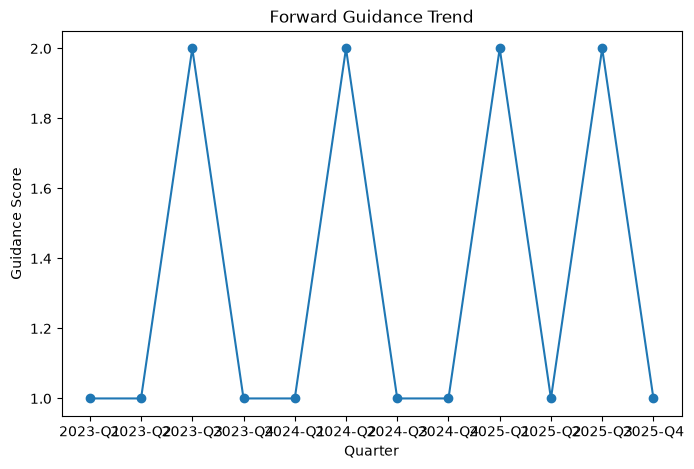

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(guidance_df["quarter"], guidance_df["guidance_score"], marker="o")

plt.title("Forward Guidance Trend")

plt.xlabel("Quarter")

plt.ylabel("Guidance Score")

plt.show()

In [15]:
guidance_df = pd.merge(
    guidance_df, financial_df[["quarter", "revenue_million"]], on="quarter"
)

In [16]:
guidance_df[["quarter", "guidance_score", "revenue_million"]]

,quarter,guidance_score,revenue_million
0,2023-Q1,1,120
1,2023-Q2,1,128
2,2023-Q3,2,138
3,2023-Q4,1,150
4,2024-Q1,1,158
5,2024-Q2,2,167
6,2024-Q3,1,174
7,2024-Q4,1,190
8,2025-Q1,2,198
9,2025-Q2,1,210


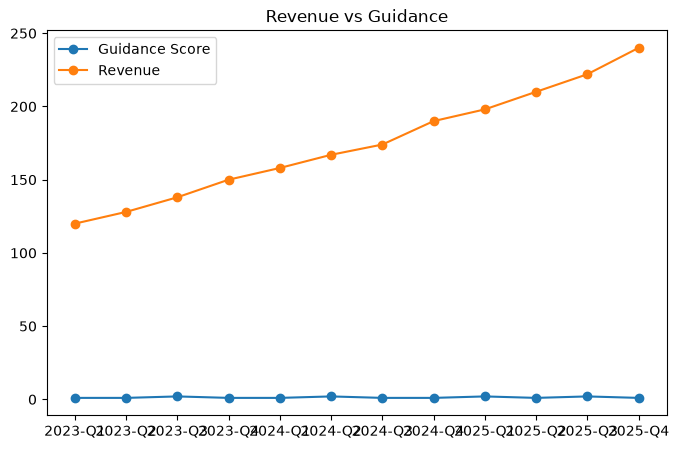

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    guidance_df["quarter"],
    guidance_df["guidance_score"],
    marker="o",
    label="Guidance Score",
)

plt.plot(
    guidance_df["quarter"], guidance_df["revenue_million"], marker="o", label="Revenue"
)

plt.legend()

plt.title("Revenue vs Guidance")

plt.show()

In [18]:
positive_guidance_words = [
    "growth",
    "strong",
    "improve",
    "expand",
    "accelerate",
    "opportunity",
    "momentum",
]

In [19]:
positive_scores = []

for statements in guidance_df["forward_statements"]:

    score = 0

    for statement in statements:

        statement = statement.lower()

        score += sum(word in statement for word in positive_guidance_words)

    positive_scores.append(score)

In [20]:
guidance_df["positive_guidance_score"] = positive_scores

In [21]:
guidance_df[["quarter", "guidance_score", "positive_guidance_score"]]

,quarter,guidance_score,positive_guidance_score
0,2023-Q1,1,1
1,2023-Q2,1,2
2,2023-Q3,2,0
3,2023-Q4,1,1
4,2024-Q1,1,0
5,2024-Q2,2,0
6,2024-Q3,1,0
7,2024-Q4,1,2
8,2025-Q1,2,2
9,2025-Q2,1,0


In [22]:
guidance_df

,ticker,quarter,forward_statements,guidance_count,guidance_score,revenue_million,positive_guidance_score
0,ABC,2023-Q1,[We expect continued growth next quarter.],1,1,120,1
1,ABC,2023-Q2,[We expect strong momentum in Q3.],1,1,128,2
2,ABC,2023-Q3,[\n Customer demand exceeded expectatio...,2,2,138,0
3,ABC,2023-Q4,[Management expects continued growth.],1,1,150,1
4,ABC,2024-Q1,[Seasonality impacted sequential expansion sli...,1,1,158,0
5,ABC,2024-Q2,[North American markets outperformed our inter...,2,2,167,0
6,ABC,2024-Q3,[\n European expansion is yielding soli...,1,1,174,0
7,ABC,2024-Q4,[We enter 2025 with strong fundamental momentu...,1,1,190,2
8,ABC,2025-Q1,[\n We carried the strong closing momen...,2,2,198,2
9,ABC,2025-Q2,[Net expansion rate among existing clients rem...,1,1,210,0


In [23]:
financial_guidance_df = pd.merge(
    financial_df,
    guidance_df[["quarter", "guidance_score", "positive_guidance_score"]],
    on="quarter",
)

In [24]:
financial_guidance_df.head()

,ticker,quarter,revenue_million,gross_margin_pct,operating_income_million,net_income_million,eps,earnings_call,risk_factors,mda_section,combined_text,clean_text,character_count,sentences,chunks,sentiment,confidence,weighted_sentiment,guidance_score,positive_guidance_score
0,ABC,2023-Q1,120,58,22,16,1.20,\n Demand remained strong across enterp...,\n Inflation remains a concern.\n ...,\n Management believes demand trends re...,\n Demand remained strong across enterp...,Demand remained strong across enterprise custo...,299,['Demand remained strong across enterprise cus...,['Demand remained strong across enterprise cus...,positive,0.956167,0.956167,1,1
1,ABC,2023-Q2,128,60,25,18,1.35,\n Enterprise adoption accelerated.\n ...,\n Competitive pressure exists.\n ...,\n New product launches contributed pos...,\n Enterprise adoption accelerated.\n ...,Enterprise adoption accelerated. Pricing press...,239,"['Enterprise adoption accelerated.', 'Pricing ...",['Enterprise adoption accelerated. Pricing pre...,positive,0.957692,0.957692,1,2
2,ABC,2023-Q3,138,61,28,21,1.52,\n Customer demand exceeded expectation...,\n Geopolitical uncertainty remains.\n ...,\n Strong customer growth across region...,\n Customer demand exceeded expectation...,Customer demand exceeded expectations. Supply ...,269,"['Customer demand exceeded expectations.', 'Su...",['Customer demand exceeded expectations. Suppl...,positive,0.951876,0.951876,2,0
3,ABC,2023-Q4,150,63,32,24,1.72,\n Record quarter performance.\n ...,\n Macroeconomic slowdown remains possi...,\n Revenue growth exceeded internal exp...,\n Record quarter performance.\n ...,Record quarter performance. Management expects...,260,"['Record quarter performance.', 'Management ex...",['Record quarter performance. Management expec...,positive,0.956653,0.956653,1,1
4,ABC,2024-Q1,158,62,34,26,1.85,\n Strong start to the fiscal year driv...,\n Increased cyber security threats req...,\n Gross margin slightly contracted due...,\n Strong start to the fiscal year driv...,Strong start to the fiscal year driven by ente...,460,['Strong start to the fiscal year driven by en...,['Strong start to the fiscal year driven by en...,positive,0.922371,0.922371,1,0


In [25]:
financial_guidance_df.to_csv("../data/financial_guidance_dataset.csv", index=False)

In [26]:
guidance_df.to_csv("../data/forward_guidance_results.csv", index=False)

In [27]:
saved_df = pd.read_csv("../data/forward_guidance_results.csv")

saved_df.head()

,ticker,quarter,forward_statements,guidance_count,guidance_score,revenue_million,positive_guidance_score
0,ABC,2023-Q1,['We expect continued growth next quarter.'],1,1,120,1
1,ABC,2023-Q2,['We expect strong momentum in Q3.'],1,1,128,2
2,ABC,2023-Q3,['\n Customer demand exceeded expectati...,2,2,138,0
3,ABC,2023-Q4,['Management expects continued growth.'],1,1,150,1
4,ABC,2024-Q1,['Seasonality impacted sequential expansion sl...,1,1,158,0
